**Análisis comparativo de mercado: Sector Tecnológico tradicional vs. Criptomonedas.**

**Abstracto y Motivación:** En los últimos años, las criptomonedas han pasado de ser un activo de nicho a formar parte de las carteras de inversión globales. La motivación de este proyecto es analizar si activos digitales como Bitcoin (BTC) se comportan de manera independiente, o si su movimiento está atado al rendimiento de las acciones del sector tecnológico tradicional (como Apple o Microsoft). Entender esta dinámica es clave para la gestión de riesgos en las finanzas modernas.

**Audiencia**: Este análisis está dirigido a gerentes de fondos de inversión, analistas financieros y pequeños inversores (retail) que buscan diversificar su portafolio y necesitan entender el riesgo y la volatilidad al combinar acciones tradicionales con criptoactivos.

**Preguntas / Hipótesis que queremos responder:**

1.	**Hipótesis de Correlació**n: ¿Existe una correlación directa entre el movimiento del precio de Bitcoin y el de las acciones de grandes empresas tecnológicas (Big Tech)?

2.	**Pregunta de Volatilidad**: ¿Es la volatilidad diaria de las criptomonedas significativamente mayor que la de las acciones tecnológicas en el período analizado?

3.	**Pregunta de Volumen**: ¿Los días con mayor volumen de transacciones en Bitcoin coinciden con las mayores caídas o subidas de su precio?


In [13]:
# instalo yfinance por si colab no lo trae actualizado
!pip install yfinance -q

In [14]:
# imports
import pandas as pd
import yfinance as yf
import requests
from datetime import datetime

In [15]:
# fuente 1: datos de apple (yahoo finance)
print("descargando AAPL...")
aapl_data = yf.download('AAPL', period='1y', interval='1d')

# me quedo con fecha y cierre
aapl_df = aapl_data[['Close']].reset_index()
aapl_df.columns = ['Fecha', 'Precio_AAPL']

# le saco el timezone a la fecha para q no tire error en el merge despues
aapl_df['Fecha'] = pd.to_datetime(aapl_df['Fecha']).dt.tz_localize(None).dt.normalize()

/tmp/ipykernel_211/1627432067.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_data = yf.download('AAPL', period='1y', interval='1d')
[*********************100%***********************]  1 of 1 completed

descargando AAPL...


In [16]:
# fuente 2: api de coingecko para btc
print("descargando btc de coingecko...")
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
parametros = {
    'vs_currency': 'usd',
    'days': '365',
    'interval': 'daily'
}

# le pego a la api
respuesta = requests.get(url, params=parametros)
datos_api = respuesta.json()

# saco los precios q vienen tipo [timestamp, precio]
precios_btc = datos_api['prices']
btc_df = pd.DataFrame(precios_btc, columns=['Timestamp', 'Precio_BTC'])

# paso el timestamp a fecha normal para hacer el join despues
btc_df['Fecha'] = pd.to_datetime(btc_df['Timestamp'], unit='ms').dt.normalize()
btc_df = btc_df.drop(columns=['Timestamp']) # vuelo la columna vieja

descargando btc de coingecko...


In [17]:
# merge de los dos datasets
print("cruzando info...")

# inner join por fecha asi vuelo los findes donde la bolsa esta cerrada
df_final = pd.merge(btc_df, aapl_df, on='Fecha', how='inner')

cruzando info...


In [18]:
# exporto el dataset a csv
df_final.to_csv('dataset_mercado_btc_aapl.csv', index=False)
print("listo, csv guardado")

# reviso las primeras filas para ver q este todo ok
df_final.head()

listo, csv guardado


,Precio_BTC,Fecha,Precio_AAPL
0,85787.709149,2025-03-24,219.772156
1,87327.729697,2025-03-25,222.779053
2,87520.583915,2025-03-26,220.568665
3,86960.855549,2025-03-27,222.878601
4,87227.271580,2025-03-28,216.954407


In [7]:
import pandas as pd
# Ahora leemos directamente el archivo local que ya descargamos!
df = pd.read_csv('dataset_mercado_btc_aapl.csv')
df['Fecha'] = pd.to_datetime(df['Fecha']) # Aseguramos que la fecha sea formato fecha
df.head()

,Precio_BTC,Fecha,Precio_AAPL
0,85787.709149,2025-03-24,219.772141
1,87327.729697,2025-03-25,222.779037
2,87520.583915,2025-03-26,220.568665
3,86960.855549,2025-03-27,222.878632
4,87227.271580,2025-03-28,216.954407


In [9]:
# Ver cuántas filas y columnas totales tenemos
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# Ver los tipos de datos (metadata)
df.info()

El dataset tiene 250 filas y 3 columnas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Precio_BTC   250 non-null    float64       
 1   Fecha        250 non-null    datetime64[ns]
 2   Precio_AAPL  250 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 6.0 KB


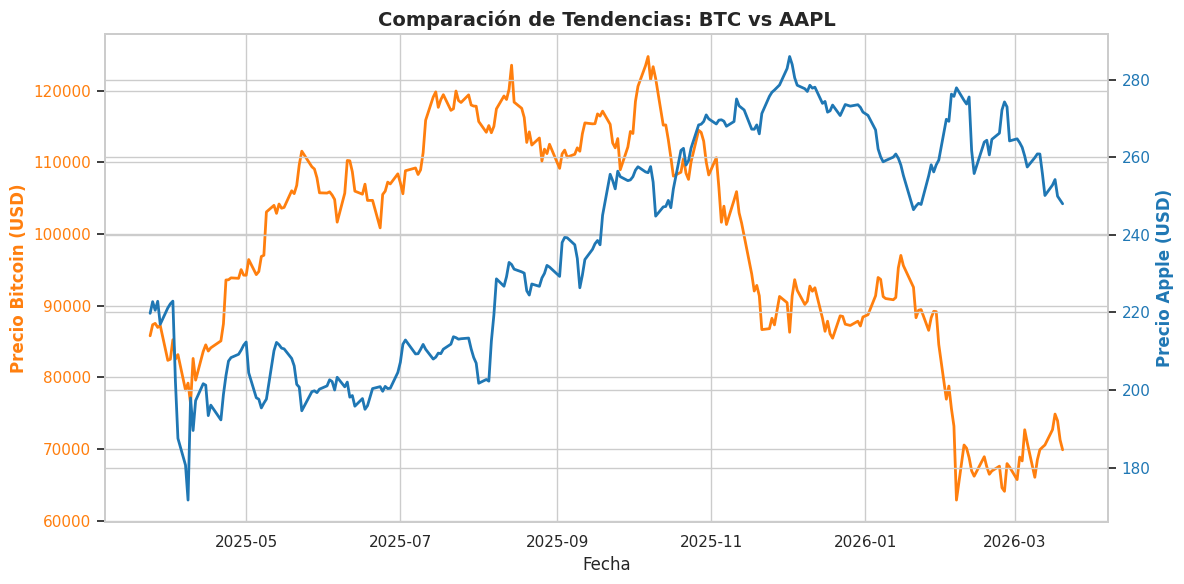

Correlación de Pearson: -0.35


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# gráfico de dos ejes para comparar btc vs apple
fig, ax1 = plt.subplots(figsize=(12, 6))

# btc en naranja (izq)
color_btc = 'tab:orange'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio Bitcoin (USD)', color=color_btc, fontweight='bold')
ax1.plot(df['Fecha'], df['Precio_BTC'], color=color_btc, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_btc)

# apple en azul (der)
ax2 = ax1.twinx()
color_aapl = 'tab:blue'
ax2.set_ylabel('Precio Apple (USD)', color=color_aapl, fontweight='bold')
ax2.plot(df['Fecha'], df['Precio_AAPL'], color=color_aapl, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_aapl)

plt.title('Comparación de Tendencias: BTC vs AAPL', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# saco la correlación
correlacion = df['Precio_BTC'].corr(df['Precio_AAPL'])
print(f"Correlación de Pearson: {correlacion:.2f}")

Se observa a simple vista que los precios no tienen una correlación positiva fuerte en este período. Mientras Bitcoin sufrió una caída abrupta (alta volatilidad), las acciones de Apple mantuvieron una tendencia alcista estable.

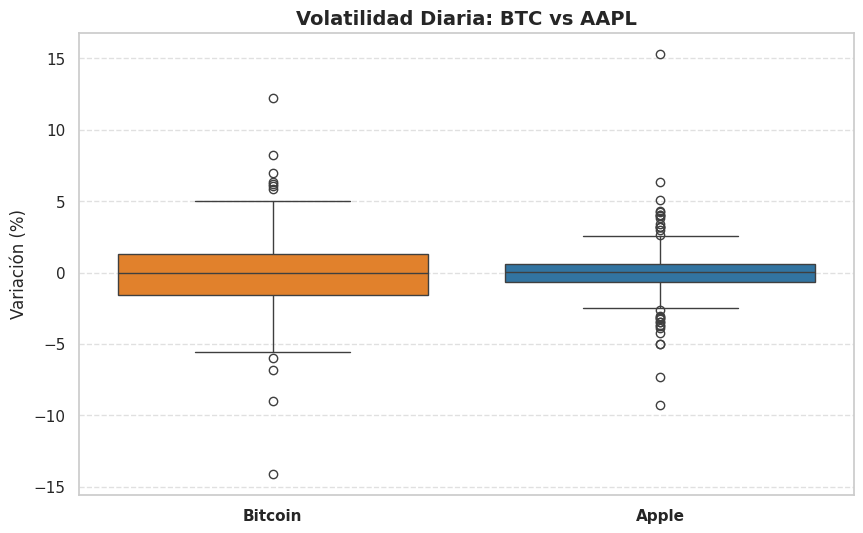

Volatilidad BTC: 2.78%
Volatilidad AAPL: 2.00%


In [20]:
# saco los retornos diarios en %
df['Retorno_BTC'] = df['Precio_BTC'].pct_change() * 100
df['Retorno_AAPL'] = df['Precio_AAPL'].pct_change() * 100

# boxplot para ver la volatilidad
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Retorno_BTC', 'Retorno_AAPL']], palette=['tab:orange', 'tab:blue'])

plt.title('Volatilidad Diaria: BTC vs AAPL', fontsize=14, fontweight='bold')
plt.ylabel('Variación (%)')
plt.xticks([0, 1], ['Bitcoin', 'Apple'], fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# saco la desviacion estandar (volatilidad)
vol_btc = df['Retorno_BTC'].std()
vol_aapl = df['Retorno_AAPL'].std()

print(f"Volatilidad BTC: {vol_btc:.2f}%")
print(f"Volatilidad AAPL: {vol_aapl:.2f}%")

El gráfico de cajas demuestra visualmente que Bitcoin tiene una dispersión mucho mayor en sus variaciones diarias. Al tener una "caja" y "bigotes" más amplios que Apple, confirmamos que es un activo considerablemente más volátil y riesgoso.

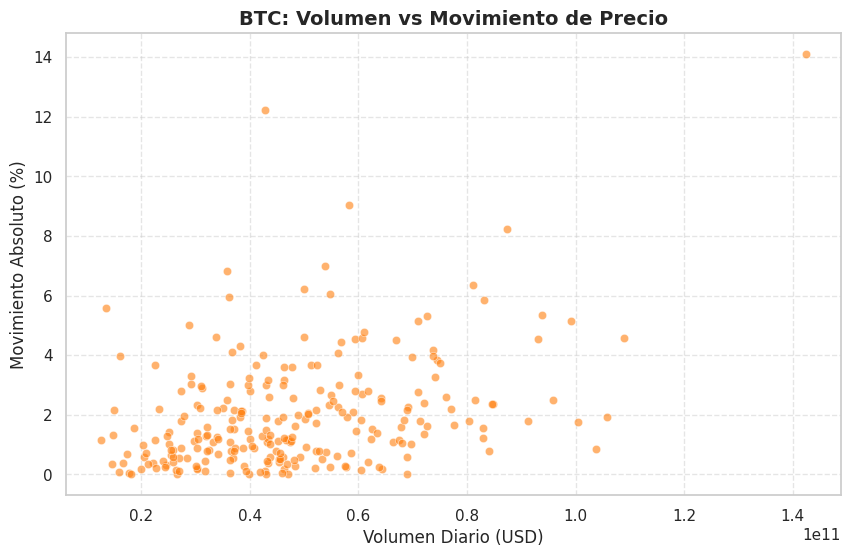

Correlación Volumen/Movimiento: 0.38


In [22]:
# pido volumen de btc a la api
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
parametros = {'vs_currency': 'usd', 'days': '365', 'interval': 'daily'}
datos_api = requests.get(url, params=parametros).json()

# armo el df de volumen y limpio fechas
vol_df = pd.DataFrame(datos_api['total_volumes'], columns=['Timestamp', 'Volumen_BTC'])
vol_df['Fecha'] = pd.to_datetime(vol_df['Timestamp'], unit='ms').dt.normalize()
vol_df = vol_df.drop(columns=['Timestamp'])

# junto todo en el df principal
df = pd.merge(df, vol_df, on='Fecha', how='inner')

# saco el valor absoluto del retorno (magnitud del movimiento)
df['Movimiento_Abs_BTC'] = df['Retorno_BTC'].abs()

# scatter plot: volumen vs movimiento
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Volumen_BTC', y='Movimiento_Abs_BTC', color='tab:orange', alpha=0.6)

plt.title('BTC: Volumen vs Movimiento de Precio', fontsize=14, fontweight='bold')
plt.xlabel('Volumen Diario (USD)')
plt.ylabel('Movimiento Absoluto (%)')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

# calculo la correlacion
corr_v = df['Volumen_BTC'].corr(df['Movimiento_Abs_BTC'])
print(f"Correlación Volumen/Movimiento: {corr_v:.2f}")

Los puntos atípicos del gráfico muestran que los mayores saltos porcentuales en el precio de Bitcoin coinciden con los días de mayor volumen operado. Esto indica que los movimientos fuertes de precio están respaldados por una alta actividad en el mercado.